# **Chương 6: Phương pháp bình phương tối thiểu**

In [ ]:
import numpy as np

def find_M(x:np, degree, decimals = 5):
    M = np.zeros((degree + 1, degree + 1), dtype = np.float32)
    for row in range(0, degree + 1):
        for col in range(row, degree + 1):
            M[row, col] = M[col, row] =  np.round(np.sum(np.power(x,row + col)), decimals= decimals)
    return M

def find_N(x: np, y: np, degree, decimals = 5):
    N = np.zeros(degree + 1)
    for col in range(N.shape[0]):
        N[col] = np.sum(y*np.power(x,col))
    return N

# Chuẩn hóa
def normalization_fx(y):
    for (i,ai) in enumerate(y):
        coef = ai.split("_")[0]
        if float(coef) == 0:
            y.remove(ai)
        else:
            y[i] = ai.replace("_", "")
    return " + ".join(y).replace("+ -", "- ")

def fx(a: np):
    y = []
    for (i,ai) in enumerate(a):
        if i == 0:
            y.append(str(ai))
        elif i == 1:
            y.append(str(ai) + "_*x")
        else:
            y.append(str(ai) + "_*x^" + str(i))
    y = normalization_fx(y)
    return y

# Vẽ đồ thị
def draw(x,y, f):
    plt.scatter(x,y, s = 30, c = "r")

    x = np.arange(x[0] - 1, x[-1] + 1, 0.001)
    y = eval(f.replace("^", "**"))
    plt.plot(x,y, label = "f(x)")
    plt.title("Đồ thị xấp xỉ")
    plt.legend()

def main(x, y, degree, decimals = 5):

    M = find_M(x,degree)
    N = find_N(x,y,degree)
    a = np.round(np.linalg.inv(M).dot(N), decimals)
    f =  fx(a)
    draw(x,y,f)
    print("f(x) =",f)

f(x) = -0.46832 + 0.43444*x


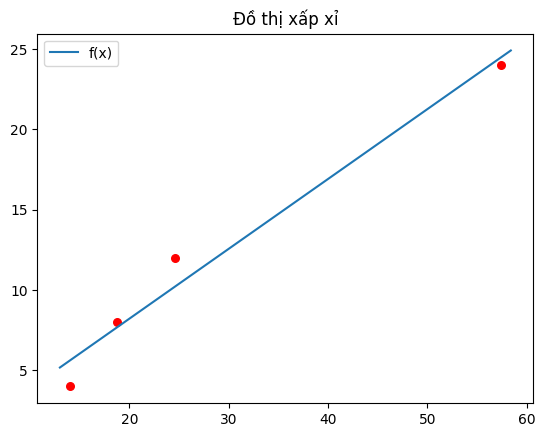

In [ ]:
## Ví dụ 1
import matplotlib.pyplot as plt

x = np.array([14.0, 18.8, 24.6, 57.4])
y = np.array([4, 8, 12.0, 24.0])
degree = 1 # bậc của hàm số
decimals = 5 # làm tròn sau dấu phảy
main(x, y, degree, decimals)

f(x) = 0.40669 + 1.15484*x + 0.03485*x^2


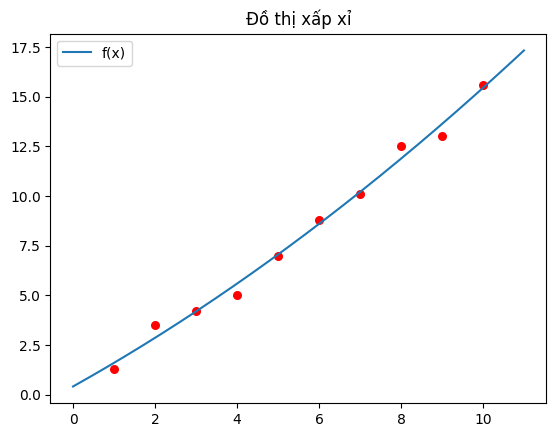

In [ ]:
## Ví dụ 2

x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([1.3, 3.5, 4.2, 5.0, 7.0, 8.8, 10.1, 12.5, 13, 15.6])
degree = 2
decimals = 5
main(x, y, degree, decimals)

# Xấp xỉ bình phương liên tục

Xấp xỉ hàm số f(x) thành đa thức
        P(x) = a0 + a1x + a2x^2 + ... + an*x^n

Tích phân đi từ a -> b của (x^i)P(x) bằng tích phân đi từ a -> b của (x^i)f(x) với i = 0, 1, ..., n.
Ta được ma trận A * coef = y

Với A là ma trận (n+1)x(n+1) và coef là ma trận hệ số a = [a0, a1, ..., an] và y là ma trận tích phân các giá trị của hàm (x^i)*f(x)

In [ ]:
def val_f(func,x):
    return eval(func.replace("^", "**"))

def simpson_rule(x, h, f_func, val_f):
    sum = 0
    for i in range(x.shape[0]):
        if i == 0 and i == x.shape[0] - 1:
            sum += val_f(f_func, x[i])
        elif i % 2 == 0:
            sum += 2*val_f(f_func, x[i])
        else:
            sum += 4*val_f(f_func, x[i])

    return h/3*sum

In [ ]:
def print_function(coef):
    Px = ""
    for i in range(coef.shape[0]):
        if i == 0 and coef[i] != 0:
            Px += "{} + ".format(coef[i])
        elif i == coef.shape[0] -1 and coef[i] != 0:
            Px += "{}*x^{} ".format(coef[i], i)
        elif i == coef.shape[0] -1 and coef[i] == 0:
            Px = Px.strip().strip("+")
        elif coef[i] != 0:
            Px += "{}*x^{} + ".format(coef[i], i)
    Px = Px.replace("^1 ", " ")
    print("P(x) =", Px)
    return Px

In [ ]:
def draw_func(a,b, fx, Px, step = 0.01):
    plt.style.use("seaborn-whitegrid")
    x = np.arange(a, b, step)
    val_fx = val_f(fx, x)
    val_Px = val_f(Px, x)
    plt.plot(x, val_fx, label = "f(x)")
    plt.plot(x, val_Px, label = "P(x)")
    plt.legend()
    plt.title("Xap xi hham so bang ham truc giao")
    plt.xlabel("x-axis")
    plt.ylabel("y-axis")

In [ ]:
def main(f_func, a, b, degree, d_decimals = 4):
    #  các tham số của cần thiết cho công thức Simpson
    n = 100
    h = (b-a)/(2*n)
    x = a + np.arange(0, 2*n + 1)*h

    A = np.zeros((degree + 1, degree + 1))
    for i in range(A.shape[0]):
        for j in range(i,A.shape[1]):
            A[i,j] = A[j, i] = simpson_rule(x,h,"x^{}".format(i + j), val_f)

    A = np.round(A, d_decimals)

    y = np.zeros(degree + 1)
    for i in range(y.shape[0]):
        new_func = "(" + f_func + ")*x^{}".format(i)
        y[i] = simpson_rule(x, h, new_func, val_f)

    coef = np.round(y.dot(np.linalg.inv(A)), d_decimals)

    Px = print_function(coef)
    draw_func(a, b, f_func, Px)
    # return coef

P(x) = 1.834 + 3.9997*x 


<ipython-input-68-f2aed8c94005>:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


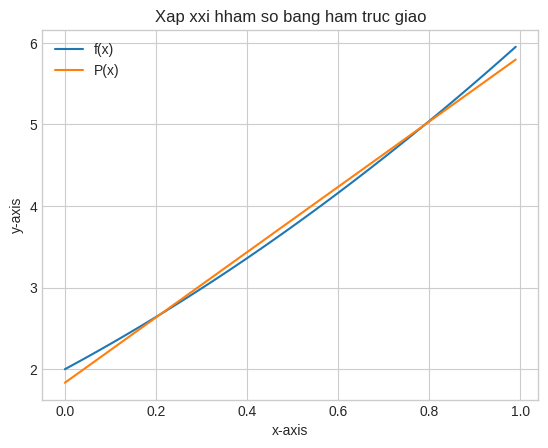

In [ ]:
## Ví dụ
if __name__ == "__main__":
    a,b = 0, 1 # khoảng làm tròn của tích phân
    f_func = "x^2 + 3*x +2"
    degree = 1 # bậc của phương trình cần xấp xỉ
    d_decimals = 4
    main(f_func, a, b, degree)